In [1]:
import numpy as np
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

In [2]:
def sphere_2d(x, y):
    return x**2 + y**2

In [3]:
def rosenbrock_2d(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

In [4]:
def project_sphere_1d(t, theta=np.pi/4, x0=1.0, y0=0.0):
    """1D slice/projection of f(x,y)=x^2+y^2 along a line parameterized by t."""
    ux, uy = np.cos(theta), np.sin(theta)
    x = x0 + t * ux
    y = y0 + t * uy
    return sphere_2d(x, y)

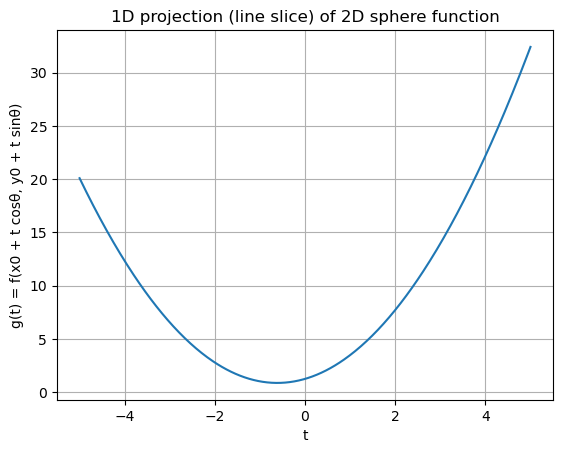

In [5]:


t = np.linspace(-5, 5, 400)

theta = np.pi / 6   # 30 degrees
x0, y0 = 1.0, -0.5  # offset (set to 0,0 to pass through origin)

g = project_sphere_1d(t, theta=theta, x0=x0, y0=y0)

plt.figure()
plt.plot(t, g)
plt.xlabel("t")
plt.ylabel("g(t) = f(x0 + t cosθ, y0 + t sinθ)")
plt.title("1D projection (line slice) of 2D sphere function")
plt.grid(True)
plt.show()


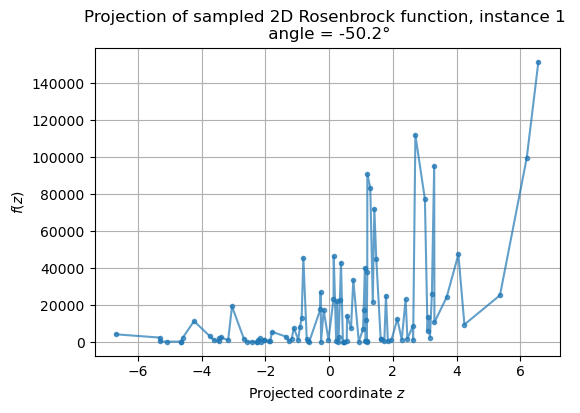

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.qmc import LatinHypercube
from ioh import get_problem

# -----------------------------
# 1) Sample points in 2D
# -----------------------------
dimension = 2
n_samples = 50*dimension
X = LatinHypercube(d=2, seed=12345).random(n_samples) * 10 - 5  # scale to [-5, 5]

# -----------------------------
# 2) Evaluate 2D sphere function
# -----------------------------
def sphere_2d(x):
    return np.sum(x**2, axis=1)

def rosenbrock_2d(x):
    return (1 - x[:, 0])**2 + 100 * (x[:, 1] - x[:, 0]**2)**2

def rastrigin_2d(x):
    A = 10
    return A * 2 + (x[:, 0]**2 - A * np.cos(2 * np.pi * x[:, 0])) + (x[:, 1]**2 - A * np.cos(2 * np.pi * x[:, 1]))

#f = sphere_2d(X)
#f = rosenbrock_2d(X)
#f = rastrigin_2d(X)
func = get_problem(fid=8,instance=1,dimension=2)
f = np.array(func(X))


# -----------------------------
# 3) Project 2D → 1D
# -----------------------------
# Random projection direction
u = np.random.randn(2)
u /= np.linalg.norm(u)  # normalize

# Get the angle of the projection for reference
angle = np.arctan2(u[1], u[0])  # in radians
angle_deg = np.degrees(angle)

# 1D projected coordinate
t = X @ u

t_sorted = np.sort(t)
f_sorted = f[np.argsort(t)]

# -----------------------------
# 4) Visualization
# -----------------------------
plt.figure(figsize=(6, 4))
#plt.scatter(t, f, s=5, alpha=0.4)
plt.plot(t_sorted, f_sorted, '-o', markersize=3, alpha=0.7)
plt.xlabel("Projected coordinate $z$")
plt.ylabel("$f(z)$")

plt.title("Projection of sampled 2D {} function, instance {} \n angle = {:.1f}°".format(func.meta_data.name,func.meta_data.instance,angle_deg))
plt.grid(True)
plt.savefig("1D_projection_{}_inst{}_angle{:.1f}.pdf".format(func.meta_data.name,func.meta_data.instance,angle_deg), bbox_inches='tight')
plt.show()


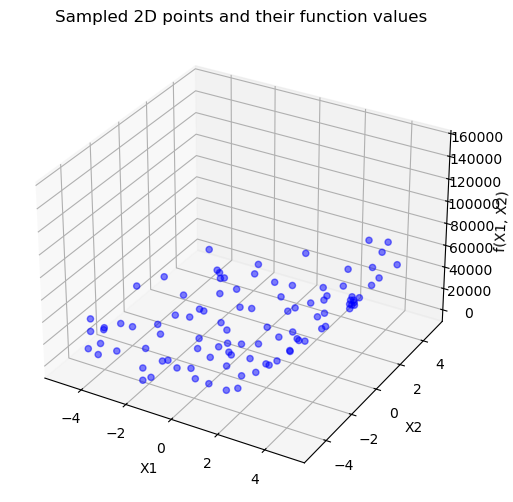

In [7]:
# Plot the original 2D points in 3D
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], f, c='b', marker='o', alpha=0.5)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('f(X1, X2)')
ax.set_title('Sampled 2D points and their function values')
plt.savefig("2D_scatter_{}_inst{}_angle{:.1f}.pdf".format(func.meta_data.name,func.meta_data.instance,angle_deg), bbox_inches='tight')
plt.show()

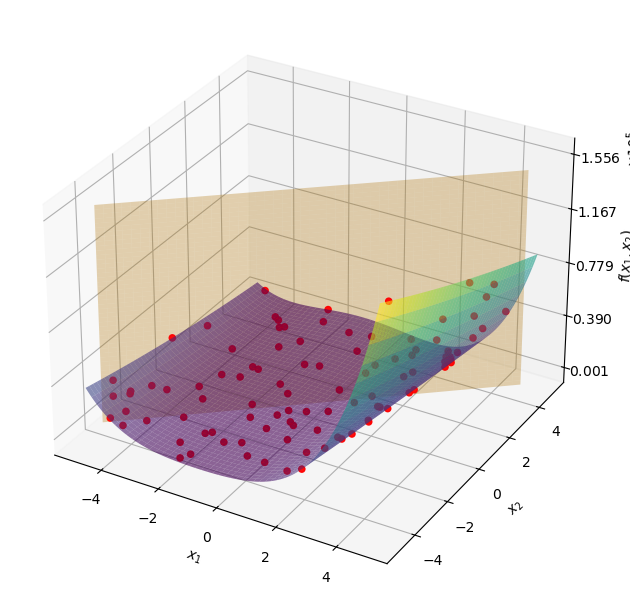

In [8]:
from scipy.interpolate import griddata


x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 200)
x2 = np.linspace(X[:, 1].min(), X[:, 1].max(), 200)
X1g, X2g = np.meshgrid(x1, x2)

#Fg = griddata(
#    points=X,
#    values=f,
#    xi=(X1g, X2g),
#    method='cubic'   # 'linear', 'nearest' also possible
#)

Fg = np.zeros(X1g.shape)

for aa in range(X1g.shape[0]):
    for bb in range(X1g.shape[1]):
        point = np.array([X1g[aa, bb], X2g[aa, bb]])
        # Find the nearest neighbor
        #distances = np.linalg.norm(X - point, axis=1)
        #nearest_index = np.argmin(distances)
        Fg[aa, bb] = func(point.tolist())

fig = plt.figure(figsize=(8, 6),  layout='constrained')
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X1g, X2g, Fg,
    cmap='viridis',
    edgecolor='none',
    alpha=0.6
)



ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$f(x_1, x_2)$')
#ax.set_title('Interpolated surface from scattered samples')
#fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

a, b, d = u[0], u[1], 0.0

zmin = min(Fg.min(), f.min())
zmax = max(Fg.max(), f.max())
z = np.linspace(zmin, zmax, 50)

if abs(b) > 1e-12:
    x = np.linspace(X[:, 0].min(), X[:, 0].max(), 50)
    Xg, Zg = np.meshgrid(x, z)
    Yg = (-a * Xg - d) / b
else:
    # vertical plane x = const
    y = np.linspace(X[:, 1].min(), X[:, 1].max(), 50)
    Yg, Zg = np.meshgrid(y, z)
    Xg = np.full_like(Yg, -d / a)

ax.plot_surface(
    Xg, Yg, Zg,
    color='orange',
    alpha=0.3
)

ax.scatter(X[:, 0], X[:, 1], f, c='red', marker='o', alpha=0.95)

fmt = ScalarFormatter(useMathText=True)
fmt.set_scientific(True)
fmt.set_powerlimits((0, 5))

ax.zaxis.set_major_formatter(fmt)
ax.zaxis.get_offset_text().set_visible(True)

ax.set_zticks(np.linspace(zmin, zmax, 5))
#fig.subplots_adjust(left=0.05, right=0.75, bottom=0.05, top=0.95)
ax.set_zlabel('$f(x_1, x_2)$', labelpad=5)
plt.savefig("2d_surf_{}_inst{}_angle{:.1f}.pdf".format(func.meta_data.name,func.meta_data.instance,angle_deg))
plt.show()

In [ ]:
print(t)

[-3.16626174  1.14108469 -2.21452912  3.68901377  1.6177967  -3.73324297
 -4.6446518  -0.80644012 -2.24714369 -0.16980785 -1.8746909  -3.04534265
 -0.91379581  2.45675977 -0.26596997  1.63040414 -3.44807711 -2.03239516
 -3.61202387  2.14010866 -2.18098803  1.19951654  1.17547927 -5.303073
  4.05528911  1.84418289  1.29184838 -2.03370632 -0.27345509 -1.10856352
 -0.01944718 -4.23534468  0.4335667  -0.66566346  0.13857397  3.00516109
  2.27876919  3.29648144  6.20032577  1.37111812 -2.26856856 -1.2434832
  3.22434386  1.08402295  0.33861157 -6.69353623 -2.41336562  0.2826568
  0.24982391  1.06440595  1.9540387   1.78332886 -1.85132803  4.24426733
 -5.2971138   2.70669923  0.2986979   0.75934261 -2.56301471 -4.64096032
 -1.78564776 -0.96902181 -0.6212736   1.15423761  0.46731284  3.10962933
  0.56588154  6.56470477 -0.70080707 -1.33972581 -3.39971873 -4.59299233
  1.19783094  0.55298211  1.17267959 -0.25148665 -0.8616601   1.12446819
 -3.44149328  0.22213008 -2.67265014  0.93201571  0.145

: 

In [10]:
uu = np.unique(t, return_counts=True)
print(uu)

(array([-4.91925002e+00, -4.85376925e+00, -4.80487409e+00, -4.60786213e+00,
       -4.30347647e+00, -4.23223976e+00, -4.18534482e+00, -4.11326428e+00,
       -3.87862585e+00, -3.84560216e+00, -3.82891710e+00, -3.81046465e+00,
       -3.78457405e+00, -3.64227259e+00, -3.55414790e+00, -3.36494909e+00,
       -3.33519878e+00, -3.32141813e+00, -3.24789194e+00, -3.22353023e+00,
       -2.88929489e+00, -2.73572323e+00, -2.73117868e+00, -2.71411159e+00,
       -2.71323307e+00, -2.58644054e+00, -2.51235151e+00, -2.30862638e+00,
       -2.30602899e+00, -2.05179557e+00, -1.75642639e+00, -1.61950309e+00,
       -1.56628271e+00, -1.52292557e+00, -1.44573637e+00, -1.44090901e+00,
       -1.43111294e+00, -1.23623298e+00, -1.15905258e+00, -1.02525547e+00,
       -9.86156358e-01, -9.52226918e-01, -5.67408412e-01, -5.50484456e-01,
       -5.25851674e-01, -4.69901543e-01, -4.04336192e-01, -3.97663900e-01,
       -4.54506492e-03,  3.19162763e-03,  7.93504654e-02,  1.86944913e-01,
        2.42463371e-01, 